In [1]:
import os
import sys
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import joblib

sys.path.append('..')
from utils import LSTM_helper

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Configuration

This LSTM uses a 30-day lookback window of meteorological and hydrologic inputs to predict daily streamflow.

**Split strategy:**
- One site is held out entirely for **spatial generalization testing** (the model never sees this site during training)
- The remaining 7 sites are split **temporally** into train and validation sets
- Train: 1980–2016
- Validation: 2017–2024

In [2]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# File paths
FILE_PATH = "../data/merged/merged_all_sites.csv"
MODEL_DIR = "model/LSTM/"
DATE_COL = "Date"
TARGET_COL = "flow_cms"

# Spatial holdout - this site is withheld entirely for testing
TEST_SITE = "10154200"  # Provo River 

# Temporal split years (applied to training sites only)
TRAIN_END_YEAR  = 2016
VAL_START_YEAR  = 2017

# Hyperparameters
LOOKBACK_DAYS  = 30
BATCH_SIZE     = 1024
EPOCHS         = 50
PATIENCE       = 8
LEARNING_RATE  = 1e-3

## Load and Preview Data

In [3]:
df = pd.read_csv(FILE_PATH)

# Clean column names
clean_cols = []
for c in df.columns:
    c = str(c).strip().replace('"', '')
    c = ''.join(ch if ch.isalnum() else '_' for ch in c)
    while '__' in c:
        c = c.replace('__', '_')
    c = c.strip('_')
    clean_cols.append(c)
df.columns = clean_cols

# Parse date and sort
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values([DATE_COL, 'gage_id']).reset_index(drop=True)
df['gage_id'] = df['gage_id'].astype(str)

print('Total rows:', len(df))
print('Sites:', sorted(df['gage_id'].unique()))
print('Date range:', df[DATE_COL].min().date(), 'to', df[DATE_COL].max().date())
df.head()

Total rows: 113627
Sites: ['10011500', '10128500', '10154200', '9217900', '9266500', '9289500', '9292000', '9299500']
Date range: 1980-01-01 to 2024-12-30


,Date,gage_id,SWE_cm_mean,dayl_s,prcp_mm_day,srad_W_m2,tmax_C,tmin_C,vp_Pa,tmean_C,...,Mixed_Forest,Shrub_Scrub,Grassland_Herbaceous,Unknown,Woody_Wetlands,Emergent_Herbaceous_Wetlands,Developed_High_Intensity,Perennial_Ice_Snow,site_no,flow_cms
0,1980-01-01,9266500,12.70,32913.80,0.0,79.08,-5.58,-9.49,297.74,-7.535,...,2.014080,12.859993,1.197154,0.048940,2.955238,0.101645,0.011294,0.0,9266500.0,0.396435
1,1980-01-01,10011500,13.72,32870.05,0.0,162.57,0.22,-7.22,355.51,-3.500,...,5.918358,17.225756,0.444367,0.000000,2.426592,0.124161,0.002178,0.0,10011500.0,0.764554
2,1980-01-01,10128500,8.13,32891.95,0.0,150.63,0.26,-5.67,400.20,-2.705,...,1.433777,10.431553,1.653812,0.125396,0.771306,0.141958,0.000000,0.0,10128500.0,1.104355
3,1980-01-01,10154200,13.21,32957.38,0.0,175.94,1.30,-7.40,350.59,-3.050,...,3.560091,11.750182,0.620782,0.178710,0.900604,0.072895,0.000000,0.0,10154200.0,1.302573
4,1980-01-02,9266500,12.70,32956.22,0.0,148.98,-6.19,-13.94,208.06,-10.065,...,2.014080,12.859993,1.197154,0.048940,2.955238,0.101645,0.011294,0.0,9266500.0,0.396435


In [4]:
# Keep only sites that have SNOTEL coverage
sites_with_snotel = df.groupby('gage_id')['SWE_cm_mean'].mean()
sites_with_snotel = sites_with_snotel[sites_with_snotel.notna()].index.tolist()
df = df[df['gage_id'].isin(sites_with_snotel)]

print('Sites with SNOTEL data:', sorted(df['gage_id'].unique()))

Sites with SNOTEL data: ['10011500', '10128500', '10154200', '9217900', '9266500', '9289500', '9292000', '9299500']


## Feature Selection

In [5]:
# Exclude non-feature columns
exclude_cols = {TARGET_COL, DATE_COL, 'gage_id', 'site_no', 'station_id', 'Unnamed_0', 'year', 'Minimum_Elevation_m', 'Maximum_Elevation_m', 'Open_Water', 'Developed_Open_Space', 'Developed_Low_Intensity', 'Developed_Medium_Intensity', 'Barren_Land', 'Deciduous_Forest', 'Evergreen_Forest', 'Mixed_Forest', 'Shrub_Scrub', 'Grassland_Herbaceous', 'Unknown', 'Woody_Wetlands', 'Emergent_Herbaceous_Wetlands', 'Developed_High_Intensity', 'Perennial_Ice_Snow', 'Average_Elevation_m', 'Average_Slope', 'Area_km2'}
numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
feature_cols = [c for c in numeric_cols if c not in exclude_cols]

print('Features:', feature_cols)
print('Target:', TARGET_COL)

Features: ['SWE_cm_mean', 'dayl_s', 'prcp_mm_day', 'srad_W_m2', 'tmax_C', 'tmin_C', 'vp_Pa', 'tmean_C']
Target: flow_cms


In [6]:
# Fill missing values per site to avoid cross-site leakage
df[feature_cols + [TARGET_COL]] = (
    df.groupby('gage_id')[feature_cols + [TARGET_COL]]
    .transform(lambda x: x.interpolate(method='linear', limit_direction='both').ffill().bfill())
)

print('Missing values remaining:')
print(df[feature_cols + [TARGET_COL]].isnull().sum())
df.head()

Missing values remaining:
SWE_cm_mean    0
dayl_s         0
prcp_mm_day    0
srad_W_m2      0
tmax_C         0
tmin_C         0
vp_Pa          0
tmean_C        0
flow_cms       0
dtype: int64


,Date,gage_id,SWE_cm_mean,dayl_s,prcp_mm_day,srad_W_m2,tmax_C,tmin_C,vp_Pa,tmean_C,...,Mixed_Forest,Shrub_Scrub,Grassland_Herbaceous,Unknown,Woody_Wetlands,Emergent_Herbaceous_Wetlands,Developed_High_Intensity,Perennial_Ice_Snow,site_no,flow_cms
0,1980-01-01,9266500,12.70,32913.80,0.0,79.08,-5.58,-9.49,297.74,-7.535,...,2.014080,12.859993,1.197154,0.048940,2.955238,0.101645,0.011294,0.0,9266500.0,0.396435
1,1980-01-01,10011500,13.72,32870.05,0.0,162.57,0.22,-7.22,355.51,-3.500,...,5.918358,17.225756,0.444367,0.000000,2.426592,0.124161,0.002178,0.0,10011500.0,0.764554
2,1980-01-01,10128500,8.13,32891.95,0.0,150.63,0.26,-5.67,400.20,-2.705,...,1.433777,10.431553,1.653812,0.125396,0.771306,0.141958,0.000000,0.0,10128500.0,1.104355
3,1980-01-01,10154200,13.21,32957.38,0.0,175.94,1.30,-7.40,350.59,-3.050,...,3.560091,11.750182,0.620782,0.178710,0.900604,0.072895,0.000000,0.0,10154200.0,1.302573
4,1980-01-02,9266500,12.70,32956.22,0.0,148.98,-6.19,-13.94,208.06,-10.065,...,2.014080,12.859993,1.197154,0.048940,2.955238,0.101645,0.011294,0.0,9266500.0,0.396435


## Spatial and Temporal Splits

- **Spatial test site**: held out entirely — the model never trains on this basin
- **Training sites**: split temporally into train (1980–2016) and validation (2017–2024)

In [7]:
# Separate held-out spatial test site
spatial_test_df = df[df['gage_id'] == TEST_SITE].copy()
train_sites_df  = df[df['gage_id'] != TEST_SITE].copy()

print(f"Spatial test site ({TEST_SITE}): {len(spatial_test_df)} rows")
print(f"Training sites: {sorted(train_sites_df['gage_id'].unique())}")

# Temporal split on training sites
train_sites_df['year'] = train_sites_df[DATE_COL].dt.year
train_df = train_sites_df[train_sites_df['year'] <= TRAIN_END_YEAR].copy()
val_df   = train_sites_df[train_sites_df['year'] >= VAL_START_YEAR].copy()

print(f"\nTrain rows: {len(train_df)} ({train_df[DATE_COL].min().date()} to {train_df[DATE_COL].max().date()})")
print(f"Val rows:   {len(val_df)} ({val_df[DATE_COL].min().date()} to {val_df[DATE_COL].max().date()})")
print(f"Spatial test rows: {len(spatial_test_df)} ({spatial_test_df[DATE_COL].min().date()} to {spatial_test_df[DATE_COL].max().date()})")

Spatial test site (10154200): 16436 rows
Training sites: ['10011500', '10128500', '9217900', '9266500', '9289500', '9292000', '9299500']

Train rows: 76744 (1980-01-01 to 2016-12-31)
Val rows:   20447 (2017-01-01 to 2024-12-30)
Spatial test rows: 16436 (1980-01-01 to 2024-12-30)


## Scale Features

Scalers are fit **only on training data** to prevent data leakage into validation or test sets.

In [8]:
os.makedirs(MODEL_DIR, exist_ok=True)

feature_scaler = MinMaxScaler()
target_scaler  = MinMaxScaler()

# Fit on training data only
feature_scaler.fit(train_df[feature_cols])
target_scaler.fit(train_df[[TARGET_COL]])

# Save scalers
joblib.dump(feature_scaler, f"{MODEL_DIR}feature_scaler.pkl")
joblib.dump(target_scaler,  f"{MODEL_DIR}target_scaler.pkl")

# Apply scaling to all splits
train_scaled        = LSTM_helper.add_scaled_columns(MODEL_DIR, feature_cols, TARGET_COL, train_df)
val_scaled          = LSTM_helper.add_scaled_columns(MODEL_DIR, feature_cols, TARGET_COL, val_df)
spatial_test_scaled = LSTM_helper.add_scaled_columns(MODEL_DIR, feature_cols, TARGET_COL, spatial_test_df)

print("Scaling complete.")

Scaling complete.


## Create Sequences for LSTM

In [9]:
X_train, y_train, d_train = LSTM_helper.make_sequences(DATE_COL, train_scaled,        LOOKBACK_DAYS, feature_cols, TARGET_COL)
X_val,   y_val,   d_val   = LSTM_helper.make_sequences(DATE_COL, val_scaled,          LOOKBACK_DAYS, feature_cols, TARGET_COL)
X_test,  y_test,  d_test  = LSTM_helper.make_sequences(DATE_COL, spatial_test_scaled, LOOKBACK_DAYS, feature_cols, TARGET_COL)

print('Train shape:        ', X_train.shape, y_train.shape)
print('Validation shape:   ', X_val.shape,   y_val.shape)
print('Spatial test shape: ', X_test.shape,  y_test.shape)

Train shape:         (76714, 30, 8) (76714,)
Validation shape:    (20417, 30, 8) (20417,)
Spatial test shape:  (16406, 30, 8) (16406,)


In [10]:
train_loader = DataLoader(LSTM_helper.SequenceDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(LSTM_helper.SequenceDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(LSTM_helper.SequenceDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

## Define and Train Model

In [11]:
model = LSTM_helper.LSTMRegressor(
    input_size  = len(feature_cols),
    hidden_size = 32,
    num_layers  = 1,
    dropout     = 0.0
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

LSTMRegressor(
  (lstm): LSTM(8, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [12]:
best_val_loss    = np.inf
best_state       = None
patience_counter = 0
history          = {'train_loss': [], 'val_loss': []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    batch_losses = []

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    train_loss = float(np.mean(batch_losses))
    val_loss, _, _ = LSTM_helper.evaluate(model, criterion, device, val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    print(f"Epoch {epoch:03d} | train loss = {train_loss:.5f} | val loss = {val_loss:.5f}")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_state       = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    torch.save(best_state, f"{MODEL_DIR}best_model.pt")
    print("Best model saved.")

Epoch 001 | train loss = 0.00647 | val loss = 0.00478
Epoch 002 | train loss = 0.00546 | val loss = 0.00468
Epoch 003 | train loss = 0.00542 | val loss = 0.00460
Epoch 004 | train loss = 0.00536 | val loss = 0.00453
Epoch 005 | train loss = 0.00530 | val loss = 0.00445
Epoch 006 | train loss = 0.00524 | val loss = 0.00436
Epoch 007 | train loss = 0.00519 | val loss = 0.00428
Epoch 008 | train loss = 0.00510 | val loss = 0.00417
Epoch 009 | train loss = 0.00503 | val loss = 0.00412
Epoch 010 | train loss = 0.00495 | val loss = 0.00398
Epoch 011 | train loss = 0.00484 | val loss = 0.00396
Epoch 012 | train loss = 0.00478 | val loss = 0.00392
Epoch 013 | train loss = 0.00474 | val loss = 0.00367
Epoch 014 | train loss = 0.00452 | val loss = 0.00360
Epoch 015 | train loss = 0.00442 | val loss = 0.00357
Epoch 016 | train loss = 0.00426 | val loss = 0.00318
Epoch 017 | train loss = 0.00400 | val loss = 0.00338
Epoch 018 | train loss = 0.00387 | val loss = 0.00325
Epoch 019 | train loss = 0.0

## Training History

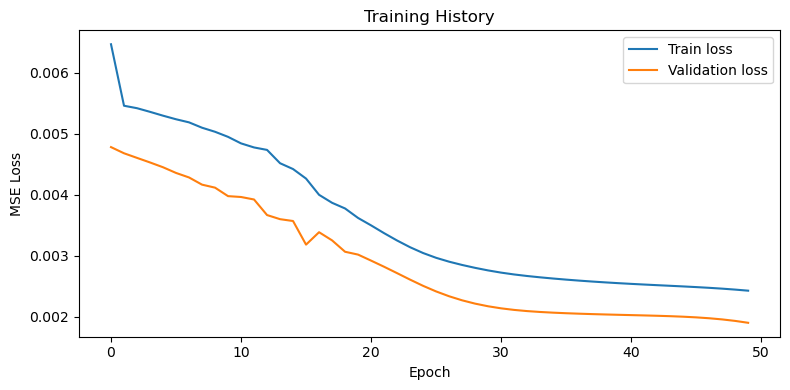

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='Train loss')
plt.plot(history['val_loss'],   label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()
plt.tight_layout()
plt.show()

## Spatial Generalization Test

Evaluating on the held-out site — the model has never seen this basin during training.

In [14]:
test_loss, test_pred_scaled, test_obs_scaled = LSTM_helper.evaluate(model, criterion, device, test_loader)

pred_flow = target_scaler.inverse_transform(test_pred_scaled.reshape(-1, 1)).ravel()
obs_flow  = target_scaler.inverse_transform(test_obs_scaled.reshape(-1, 1)).ravel()

rmse = math.sqrt(mean_squared_error(obs_flow, pred_flow))
mae  = mean_absolute_error(obs_flow, pred_flow)
r2   = r2_score(obs_flow, pred_flow)

print(f"Spatial Test Site: {TEST_SITE}")
print(f"Test MSE (scaled): {test_loss:.5f}")
print(f"RMSE:              {rmse:.4f} cms")
print(f"MAE:               {mae:.4f} cms")
print(f"R²:                {r2:.4f}")

Spatial Test Site: 10154200
Test MSE (scaled): 0.00760
RMSE:              7.7270 cms
MAE:               3.3363 cms
R²:                0.3884


## Observed vs Predicted — Time Series

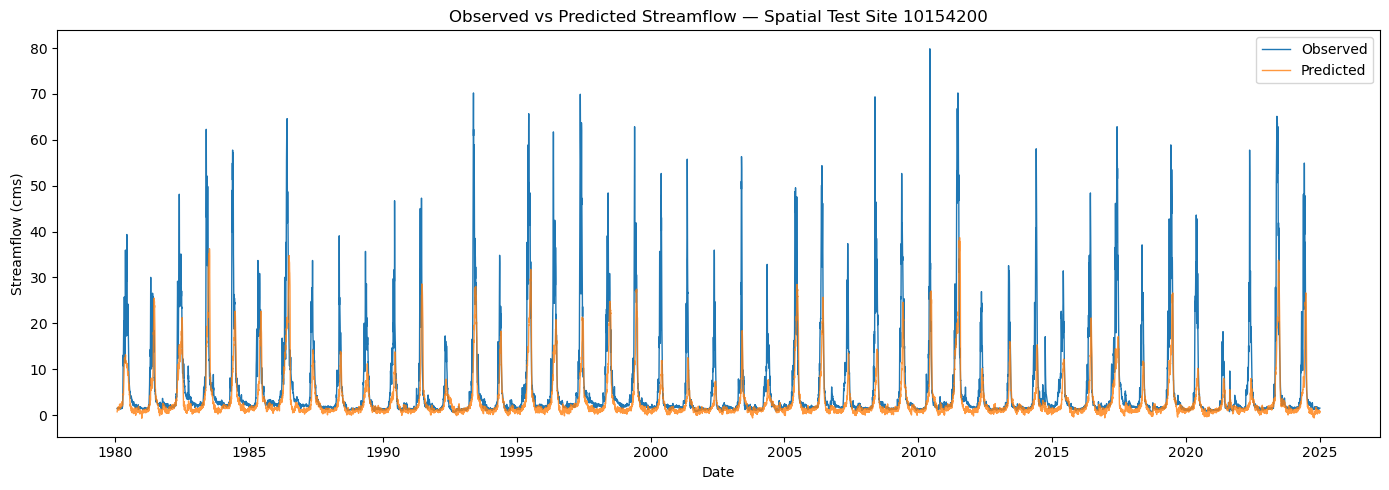

In [15]:
plt.figure(figsize=(14, 5))
plt.plot(d_test, obs_flow,  label='Observed',  linewidth=1)
plt.plot(d_test, pred_flow, label='Predicted', linewidth=1, alpha=0.8)
plt.xlabel('Date')
plt.ylabel('Streamflow (cms)')
plt.title(f'Observed vs Predicted Streamflow — Spatial Test Site {TEST_SITE}')
plt.legend()
plt.tight_layout()
plt.show()

## Observed vs Predicted — Scatter

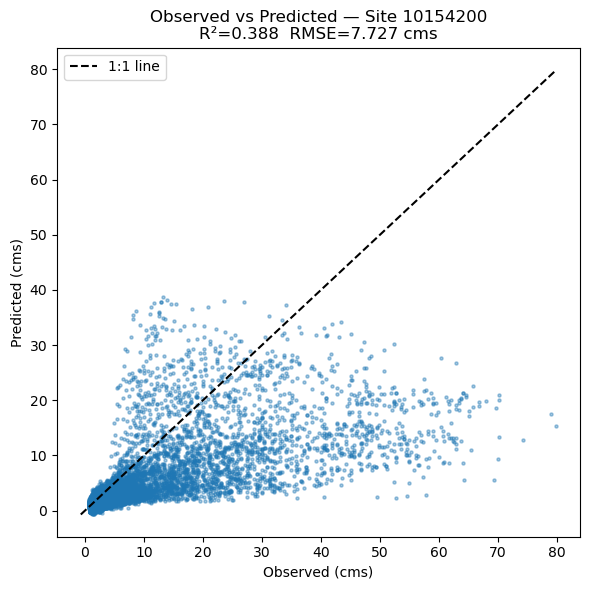

In [16]:
plt.figure(figsize=(6, 6))
plt.scatter(obs_flow, pred_flow, alpha=0.4, s=5)
lims = [min(obs_flow.min(), pred_flow.min()), max(obs_flow.max(), pred_flow.max())]
plt.plot(lims, lims, 'k--', label='1:1 line')
plt.xlabel('Observed (cms)')
plt.ylabel('Predicted (cms)')
plt.title(f'Observed vs Predicted — Site {TEST_SITE}\nR²={r2:.3f}  RMSE={rmse:.3f} cms')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
print(train_df.groupby('gage_id')[['Area_km2', 'Average_Elevation_m']].first())

            Area_km2  Average_Elevation_m
gage_id                                  
10011500  797.522121          2958.477295
10128500  735.830794          2756.079590
9217900   586.300876          3178.271240
9266500   460.524269          2879.059326
9289500   355.665972          3280.179932
9292000   473.272797          3260.164062
9299500   529.432361          3126.582764


In [18]:
# Evaluate model on each individual training site
site_results = []

for gage_id in sorted(train_sites_df['gage_id'].unique()):
    # Get this site's data
    site_df = train_sites_df[train_sites_df['gage_id'] == gage_id].copy()
    
    # Scale using the already-fitted scalers
    site_scaled = LSTM_helper.add_scaled_columns(MODEL_DIR, feature_cols, TARGET_COL, site_df)
    
    # Make sequences
    X_site, y_site, d_site = LSTM_helper.make_sequences(DATE_COL, site_scaled, LOOKBACK_DAYS, feature_cols, TARGET_COL)
    
    # Create dataloader
    site_loader = DataLoader(LSTM_helper.SequenceDataset(X_site, y_site), batch_size=BATCH_SIZE, shuffle=False)
    
    # Evaluate
    site_loss, site_pred_scaled, site_obs_scaled = LSTM_helper.evaluate(model, criterion, device, site_loader)
    
    # Inverse transform
    site_pred = target_scaler.inverse_transform(site_pred_scaled.reshape(-1, 1)).ravel()
    site_obs  = target_scaler.inverse_transform(site_obs_scaled.reshape(-1, 1)).ravel()
    
    # Compute metrics
    site_results.append({
        "gage_id": gage_id,
        "split":   "train/val",
        "NSE":     r2_score(site_obs, site_pred),
        "RMSE":    math.sqrt(mean_squared_error(site_obs, site_pred)),
        "MAE":     mean_absolute_error(site_obs, site_pred),
    })

# Add the spatial test site result
site_results.append({
    "gage_id": TEST_SITE,
    "split":   "spatial test (held out)",
    "NSE":     r2,
    "RMSE":    rmse,
    "MAE":     mae,
})

results_df = pd.DataFrame(site_results).set_index("gage_id")
print(results_df.round(3))

                            split    NSE   RMSE    MAE
gage_id                                               
10011500                train/val  0.447  6.902  2.842
10128500                train/val  0.459  6.702  2.980
9217900                 train/val  0.484  5.815  2.705
9266500                 train/val  0.438  3.300  1.577
9289500                 train/val  0.336  4.415  1.965
9292000                 train/val  0.182  4.089  2.014
9299500                 train/val  0.515  3.189  1.350
10154200  spatial test (held out)  0.388  7.727  3.336


In [19]:
results_df.round(3).to_csv("../data/performance_summary.csv")